In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Setting random seeds for reproducibility
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
train_df = pd.read_csv('data/train_processed.csv')
feature_cols = joblib.load('data/feature_columns.pkl')

In [4]:
def build_sequences(df, sequence_length=50):
    """
    Transform tabular engine data into sequential format for LSTM.

    Each sequence contains the previous 'sequence_length'
    operational cycles used to estimate current RUL.
    """

    sequence_data = []
    rul_targets = []

    # Process engine-wise data
    for engine_id in df["unit_id"].unique():

        engine_data = (
            df[df["unit_id"] == engine_id]
            .sort_values("time_cycles")
        )

        # Feature matrix and target vector
        features = engine_data[feature_cols].to_numpy()
        rul_values = engine_data["RUL"].to_numpy()

        # Generate rolling sequences
        for idx in range(sequence_length, len(features)):

            # Previous timesteps
            sequence = features[idx-sequence_length:idx]

            # Current RUL value
            target_value = rul_values[idx]

            sequence_data.append(sequence)
            rul_targets.append(target_value)

    return (np.array(sequence_data), np.array(rul_targets))

In [5]:
# Create sequences
sequence_length = 50
print(f"\nCreating sequences with window size: {sequence_length} cycles")


Creating sequences with window size: 50 cycles


In [6]:
X, y = build_sequences(train_df, sequence_length)

In [7]:
print("\nSequence generation completed successfully!")

print(f"Input sequence shape : {X.shape}")
print(f"Output target shape  : {y.shape}")

print("\nSequence Details:")
print(f"  • Total samples generated : {X.shape[0]:,}")
print(f"  • Timesteps per sample    : {X.shape[1]}")
print(f"  • Features in each step   : {X.shape[2]}")


Sequence generation completed successfully!
Input sequence shape : (15631, 50, 17)
Output target shape  : (15631,)

Sequence Details:
  • Total samples generated : 15,631
  • Timesteps per sample    : 50
  • Features in each step   : 17


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# **LSTM**

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, sequence_length):
        super(LSTMModel, self).__init__()

        # First LSTM layer (returns sequences for next LSTM)
        self.lstm1 = nn.LSTM(input_size, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)

        # Second LSTM layer
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)

        # Dense layers
        self.fc1 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)

        # Output layer (single value = RUL prediction)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # x shape: (batch, sequence_length, input_size)

        # First LSTM — return_sequences=True → pass all timesteps
        out, _ = self.lstm1(x)                  # (batch, seq_len, 128)
        out = self.dropout1(out)

        # Second LSTM — return_sequences=False → take last timestep only
        out, _ = self.lstm2(out)                # (batch, seq_len, 64)
        out = out[:, -1, :]                     # (batch, 64)  ← key difference vs Keras
        out = self.dropout2(out)

        # Dense layers
        out = self.fc1(out)                     # (batch, 32)
        out = self.relu(out)
        out = self.dropout3(out)

        # Output
        out = self.fc2(out)                     # (batch, 1)
        return out


In [10]:
input_size = X.shape[2]
model = LSTMModel(input_size=input_size, sequence_length=sequence_length)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

LSTMModel(
  (lstm1): LSTM(17, 128, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Total params:     127,041
Trainable params: 127,041


In [11]:
try:
    import torchinfo
except ImportError:
    !pip install -qq torchinfo
    import torchinfo

torchinfo.summary(model, input_size=(1, sequence_length, X.shape[2]))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [1, 1]                    --
├─LSTM: 1-1                              [1, 50, 128]              75,264
├─Dropout: 1-2                           [1, 50, 128]              --
├─LSTM: 1-3                              [1, 50, 64]               49,664
├─Dropout: 1-4                           [1, 64]                   --
├─Linear: 1-5                            [1, 32]                   2,080
├─ReLU: 1-6                              [1, 32]                   --
├─Dropout: 1-7                           [1, 32]                   --
├─Linear: 1-8                            [1, 1]                    33
Total params: 127,041
Trainable params: 127,041
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.25
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.51
Estimated Total Size (MB): 0.59

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Convert numpy arrays to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N, 1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64, shuffle=False)

model = model.to(device)


Using device: cuda


In [13]:
# ── Training Setup ────────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau — equivalent to Keras callback
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

In [14]:
# ── Training Loop (EarlyStopping + ReduceLR) ──────────────────────
print("TRAINING LSTM")

epochs        = 100
patience      = 15          # EarlyStopping patience
best_val_loss = float('inf')
best_weights  = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

for epoch in range(1, epochs + 1):
    # ── Train ──
    model.train()
    train_loss, train_mae = 0.0, 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_mae  += torch.mean(torch.abs(preds - y_batch)).item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_mae  /= len(train_loader.dataset)

    # ── Validate ──
    model.eval()
    val_loss, val_mae = 0.0, 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds    = model(X_batch)
            loss     = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            val_mae  += torch.mean(torch.abs(preds - y_batch)).item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_mae  /= len(val_loader.dataset)

    # ── Log ──
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    print(f"Epoch {epoch:3d}/{epochs} — "
          f"loss: {train_loss:.4f}  mae: {train_mae:.4f}  "
          f"val_loss: {val_loss:.4f}  val_mae: {val_mae:.4f}")

    # ── ReduceLROnPlateau step ──
    scheduler.step(val_loss)

    # ── EarlyStopping ──
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            print(f"Restoring best weights (val_loss: {best_val_loss:.4f})")
            break

TRAINING LSTM
Epoch   1/100 — loss: 7053.4846  mae: 65.3159  val_loss: 3565.9359  val_mae: 46.4177
Epoch   2/100 — loss: 3436.4497  mae: 46.8778  val_loss: 3281.2927  val_mae: 45.8234
Epoch   3/100 — loss: 3404.0165  mae: 47.0957  val_loss: 3280.5079  val_mae: 45.8426
Epoch   4/100 — loss: 3394.4733  mae: 46.9885  val_loss: 3282.1421  val_mae: 45.8061
Epoch   5/100 — loss: 3420.5592  mae: 47.0625  val_loss: 3282.4375  val_mae: 45.8018
Epoch   6/100 — loss: 3423.0767  mae: 47.0944  val_loss: 3279.9777  val_mae: 45.8587
Epoch   7/100 — loss: 3406.3824  mae: 46.9367  val_loss: 3284.9146  val_mae: 45.7708
Epoch   8/100 — loss: 3407.5547  mae: 46.9773  val_loss: 3279.7553  val_mae: 45.8667
Epoch   9/100 — loss: 3402.2703  mae: 47.0147  val_loss: 3281.7527  val_mae: 45.8135
Epoch  10/100 — loss: 3438.0989  mae: 47.0786  val_loss: 3296.8254  val_mae: 45.7027
Epoch  11/100 — loss: 3160.1199  mae: 44.3327  val_loss: 1672.0196  val_mae: 27.9247
Epoch  12/100 — loss: 1220.1765  mae: 23.8980  val_

In [15]:
def predict(model, X_numpy, device, batch_size=64):
    """Run inference on a numpy array, return numpy predictions."""
    model.eval()
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    preds    = []

    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())

    return np.concatenate(preds).flatten()

In [16]:
# ── Predictions ───────────────────────────────────────────────────
y_train_pred = predict(model, X_train, device)
y_val_pred   = predict(model, X_val,   device)

# ── Metrics ───────────────────────────────────────────────────────
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae  = mean_absolute_error(y_val, y_val_pred)
val_r2   = r2_score(y_val, y_val_pred)

print(f"\n LSTM Results:")
print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:.2f} cycles")
print(f"  MAE:  {train_mae:.2f} cycles")
print(f"  R²:   {train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  RMSE: {val_rmse:.2f} cycles")
print(f"  MAE:  {val_mae:.2f} cycles")
print(f"  R²:   {val_r2:.4f}")


 LSTM Results:

Training Set:
  RMSE: 18.42 cycles
  MAE:  12.05 cycles
  R²:   0.8959

Validation Set:
  RMSE: 18.96 cycles
  MAE:  12.45 cycles
  R²:   0.8904


# **Visualizations**

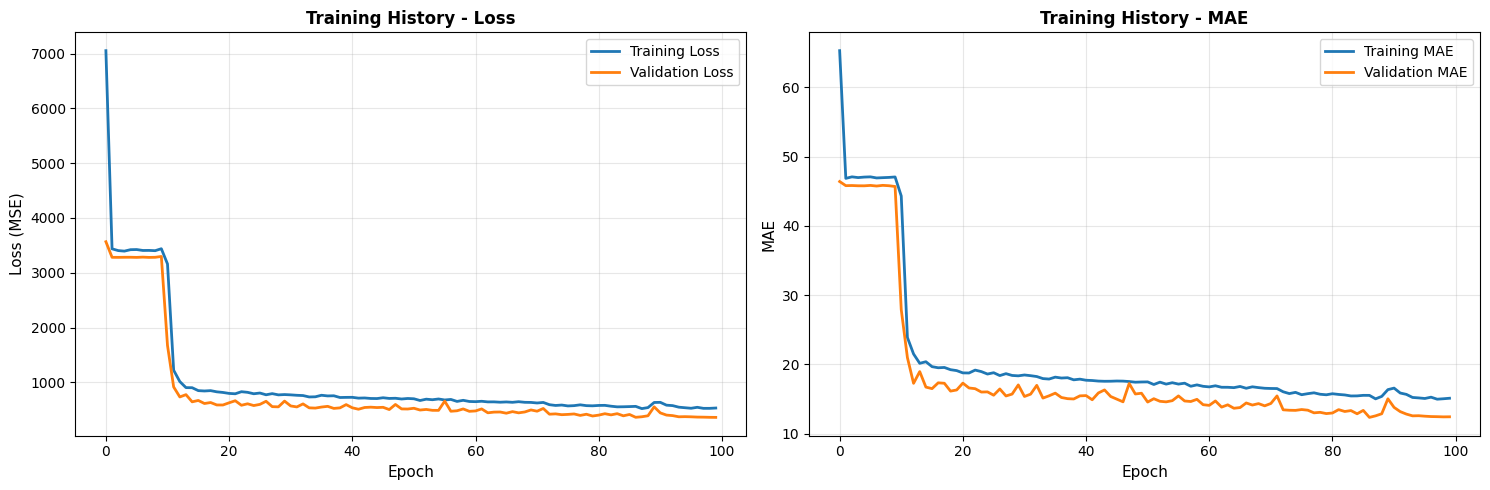

In [17]:
# ── 1. Training History ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('Training History - Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['train_mae'], label='Training MAE', linewidth=2)
axes[1].plot(history['val_mae'],   label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('Training History - MAE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

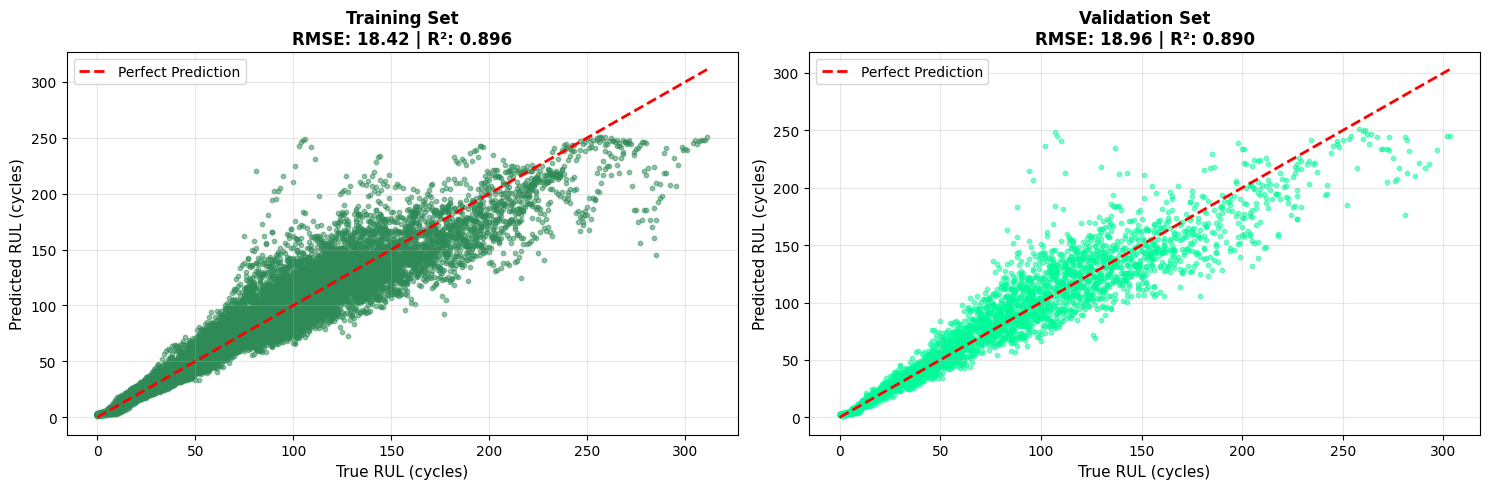

In [18]:
# ── 2. Predictions vs Actual ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10, color='seagreen')
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True RUL (cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[0].set_title(f'Training Set\nRMSE: {train_rmse:.2f} | R²: {train_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=10, color='mediumspringgreen')
axes[1].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('True RUL (cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[1].set_title(f'Validation Set\nRMSE: {val_rmse:.2f} | R²: {val_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()